In [43]:
import pandas as pd
import matplotlib.pyplot as plt 
from scipy.stats import chi2_contingency
from pathlib import Path

In [44]:
#Create a path to load the csv file New York arrest data year to date. 
DATA_PATH = (
    Path("Data_Project_1")
    /"NYPD_Arrest_Data__Year_to_Date__20240702.csv"
)

nypd_df = pd.read_csv(DATA_PATH)

In [45]:
# Rename CSV columns using consistent snake_case names.

COLUMN_NAMES = {
    "ARREST_KEY": "arrest_key",
    "ARREST_DATE": "arrest_date",
    "PD_CD": "pd_code",
    "PD_DESC": "pd_description",
    "KY_CD": "key_code",
    "OFNS_DESC": "offense_type",
    "LAW_CODE": "law_code",
    "LAW_CAT_CD": "offense_level",
    "ARREST_BORO": "borough",
    "JURISDICTION_CODE": "jurisdiction_code",
    "ARREST_PRECINCT": "arrest_precinct",
    "AGE_GROUP": "age_group",
    "PERP_SEX": "gender",
    "PERP_RACE": "race",
    "X_COORD_CD": "x_coordinate",
    "Y_COORD_CD": "y_coordinate",
    "Latitude": "latitude",
    "Longitude": "longitude",
    "New Georeferenced Column": "georeferenced_column",
}

arrests_df = nypd_df.rename(
    columns=COLUMN_NAMES
).copy()

arrests_df.head()



,arrest_key,arrest_date,pd_code,pd_description,key_code,offense_type,law_code,offense_level,borough,jurisdiction_code,arrest_precinct,age_group,gender,race,x_coordinate,y_coordinate,latitude,longitude,georeferenced_column
0,280255493,01/10/2024,397.0,"ROBBERY,OPEN AREA UNCLASSIFIED",105.0,ROBBERY,PL 1601001,F,M,0,26,<18,M,BLACK,996342,236149,40.814845,-73.956312,POINT (-73.956312 40.814845)
1,279805419,01/02/2024,157.0,RAPE 1,104.0,RAPE,PL 1303501,F,K,0,77,25-44,M,WHITE HISPANIC,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)
2,279895750,01/03/2024,101.0,ASSAULT 3,344.0,ASSAULT 3 & RELATED OFFENSES,PL 1200001,M,Q,0,106,65+,F,WHITE,1026836,180689,40.662526,-73.846499,POINT (-73.846499 40.662526)
3,280809090,01/19/2024,511.0,"CONTROLLED SUBSTANCE, POSSESSI",235.0,DANGEROUS DRUGS,PL 2200300,M,B,0,49,45-64,M,BLACK,1027430,251104,40.855793,-73.843908,POINT (-73.843908 40.855793)
4,280357135,01/11/2024,109.0,"ASSAULT 2,1,UNCLASSIFIED",106.0,FELONY ASSAULT,PL 1200502,F,K,2,81,25-44,F,BLACK,1002457,192292,40.694456,-73.934343,POINT (-73.934343 40.694456)


In [46]:
#Create a function to plot all necessary charts and elimiate redundant code. 

def plot_category_counts(
        df,
        column,
        title,
        xlabel,
        top_n=None,
        color="steelblue",
):
    counts = df[column].value_counts().head(top_n)

    ax = counts.sort_values().plot(
        kind="barh",
        figsize=(8,5),
        color=color,
    )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

    return counts 

In [47]:
# Inspect the dataset dimensions and the column data types. 

print(f"rows: {arrests_df.shape[0]:,}")
print(f"columns: {arrests_df.shape[1]}")

rows: 63,621
columns: 19


In [48]:
# Count and calculate the percentage of missing values. 

missing_values = pd.DataFrame({
    "missing_count": arrests_df.isna().sum(),
    "missing_percentage": (
        arrests_df.isna().mean() * 100
    ).round(2),
})

missing_values = missing_values[
    missing_values["missing_count"] > 0
].sort_values(
    by= "missing_percentage",
    ascending=False,
)

missing_values

,missing_count,missing_percentage
offense_level,402,0.63
key_code,9,0.01
pd_code,2,0.00


In [49]:
# Check for duplicated rows and duplicated arrests keys.

duplicate_rows = arrests_df.duplicated().sum()
duplicate_arrest_keys = arrests_df["arrest_key"].duplicated().sum()

print(f"Fully duplicated rows: {duplicate_rows:,}")
print(f"Duplicated arrest keys: {duplicate_arrest_keys:,}")

Fully duplicated rows: 0
Duplicated arrest keys: 0


In [50]:
# Examine the unique values in important categorical columns. 

category_columns = [
    "borough",
    "offense_level",
    "age_group", 
    "gender",
    "race",
]

for column in category_columns:
    print(f"\n{column.upper()}")
    print(arrests_df[column].value_counts(dropna=False))


BOROUGH
borough
K    17402
M    15324
B    14221
Q    13782
S     2892
Name: count, dtype: int64

OFFENSE_LEVEL
offense_level
M         35580
F         26653
V           775
NaN         402
9           155
I            54
(null)        2
Name: count, dtype: int64

AGE_GROUP
age_group
25-44    37254
45-64    12315
18-24    10684
<18       2327
65+       1041
Name: count, dtype: int64

GENDER
gender
M    52432
F    11189
Name: count, dtype: int64

RACE
race
BLACK                             29466
WHITE HISPANIC                    17191
WHITE                              6607
BLACK HISPANIC                     6336
ASIAN / PACIFIC ISLANDER           3543
UNKNOWN                             293
AMERICAN INDIAN/ALASKAN NATIVE      185
Name: count, dtype: int64


In [51]:
def clean_arrest_data(df):
    """Clean and prepare NYPD arrest data for analysis."""

    cleaned_df = df.copy()

    # Select text columns.
    text_columns = cleaned_df.select_dtypes(
        include="str"
    ).columns

    # Remove leading and trailing spaces.
    for column in text_columns:
        cleaned_df[column] = cleaned_df[column].str.strip()

    # Replace blank and null-like strings with missing values.
    cleaned_df[text_columns] = cleaned_df[
        text_columns
    ].replace(
        {
            "": pd.NA,
            "(null)": pd.NA,
        }
    )

    # Convert classification codes to nullable integers.
    code_columns = [
    "pd_code",
    "key_code",
    ]

    for column in code_columns:
        cleaned_df[column] = (
            pd.to_numeric(
            cleaned_df[column],
            errors="coerce",
        )
        .astype("Int64")
    )



    # Convert arrest date to datetime.
    cleaned_df["arrest_date"] = pd.to_datetime(
        cleaned_df["arrest_date"],
        errors="coerce",
    )

    # Convert coordinates to numeric values.
    cleaned_df["latitude"] = pd.to_numeric(
        cleaned_df["latitude"],
        errors="coerce",
    )

    cleaned_df["longitude"] = pd.to_numeric(
        cleaned_df["longitude"],
        errors="coerce",
    )

    # Remove completely duplicated records.
    cleaned_df = cleaned_df.drop_duplicates()

    # Remove duplicated arrest keys.
    cleaned_df = cleaned_df.drop_duplicates(
        subset="arrest_key",
        keep="first",
    )

    # Replace missing categorical values.
    categorical_columns = [
        "borough",
        "offense_type",
        "offense_level",
        "age_group",
        "gender",
        "race",
    ]

    cleaned_df[categorical_columns] = cleaned_df[
        categorical_columns
    ].fillna("UNKNOWN")


    return cleaned_df

In [52]:
cleaned_arrests_df = clean_arrest_data(arrests_df)

print(f"Original records: {len(arrests_df):,}")
print(f"Cleaned records: {len(cleaned_arrests_df):,}")

cleaned_arrests_df.head(20)

Original records: 63,621
Cleaned records: 63,621


,arrest_key,arrest_date,pd_code,pd_description,key_code,offense_type,law_code,offense_level,borough,jurisdiction_code,arrest_precinct,age_group,gender,race,x_coordinate,y_coordinate,latitude,longitude,georeferenced_column
0,280255493,2024-01-10,397,"ROBBERY,OPEN AREA UNCLASSIFIED",105,ROBBERY,PL 1601001,F,M,0,26,<18,M,BLACK,996342,236149,40.814845,-73.956312,POINT (-73.956312 40.814845)
1,279805419,2024-01-02,157,RAPE 1,104,RAPE,PL 1303501,F,K,0,77,25-44,M,WHITE HISPANIC,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)
2,279895750,2024-01-03,101,ASSAULT 3,344,ASSAULT 3 & RELATED OFFENSES,PL 1200001,M,Q,0,106,65+,F,WHITE,1026836,180689,40.662526,-73.846499,POINT (-73.846499 40.662526)
3,280809090,2024-01-19,511,"CONTROLLED SUBSTANCE, POSSESSI",235,DANGEROUS DRUGS,PL 2200300,M,B,0,49,45-64,M,BLACK,1027430,251104,40.855793,-73.843908,POINT (-73.843908 40.855793)
4,280357135,2024-01-11,109,"ASSAULT 2,1,UNCLASSIFIED",106,FELONY ASSAULT,PL 1200502,F,K,2,81,25-44,F,BLACK,1002457,192292,40.694456,-73.934343,POINT (-73.934343 40.694456)
5,281488967,2024-02-01,157,RAPE 1,104,RAPE,PL 1303501,F,Q,0,113,25-44,M,BLACK,1046315,187088,40.679981,-73.776234,POINT (-73.7762339071953 40.6799807384666)
6,280769124,2024-01-19,464,JOSTLING,230,JOSTLING,PL 1652501,M,M,0,6,25-44,M,BLACK,984134,207984,40.737547,-74.000415,POINT (-74.000415 40.737547)
7,281338081,2024-01-30,101,ASSAULT 3,344,ASSAULT 3 & RELATED OFFENSES,PL 1200001,M,M,0,26,25-44,M,BLACK,996014,236126,40.814780,-73.957499,POINT (-73.957499 40.81478)
8,280961365,2024-01-23,<NA>,NaN,<NA>,UNKNOWN,NaN,UNKNOWN,M,97,5,25-44,M,BLACK,983903,200257,40.716337,-74.001251,POINT (-74.001251 40.716337)
9,281426006,2024-01-31,155,RAPE 2,104,RAPE,PL 1303001,F,B,0,41,18-24,M,BLACK,1013037,236657,40.816206,-73.896001,POINT (-73.8960011932583 40.8162058439227)


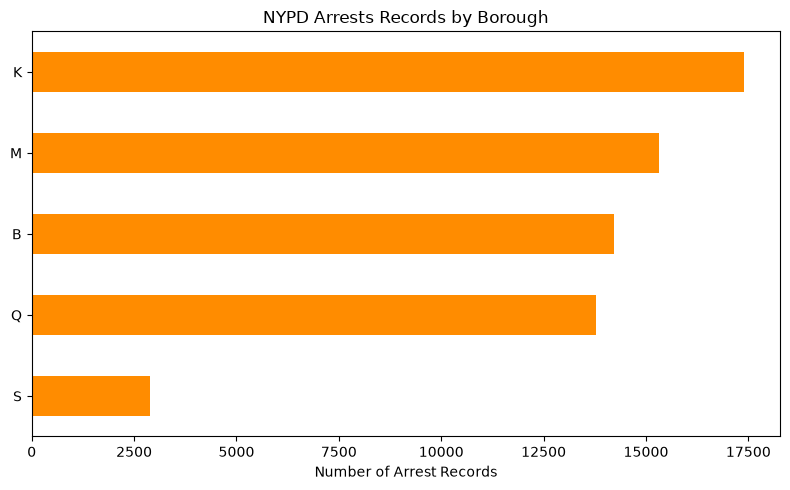

borough
K    17402
M    15324
B    14221
Q    13782
S     2892
Name: count, dtype: int64

In [53]:
plot_category_counts(
    cleaned_arrests_df,
    column= "borough",
    title="NYPD Arrests Records by Borough",
    xlabel="Number of Arrest Records",
    color="darkorange",
)

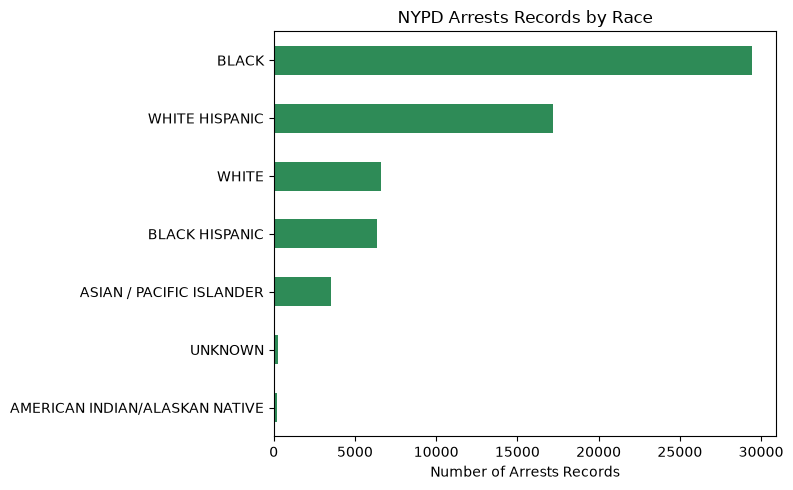

race
BLACK                             29466
WHITE HISPANIC                    17191
WHITE                              6607
BLACK HISPANIC                     6336
ASIAN / PACIFIC ISLANDER           3543
UNKNOWN                             293
AMERICAN INDIAN/ALASKAN NATIVE      185
Name: count, dtype: int64

In [54]:
plot_category_counts(
    cleaned_arrests_df,
    column= "race",
    title="NYPD Arrests Records by Race",
    xlabel="Number of Arrests Records",
    color="seagreen",
)

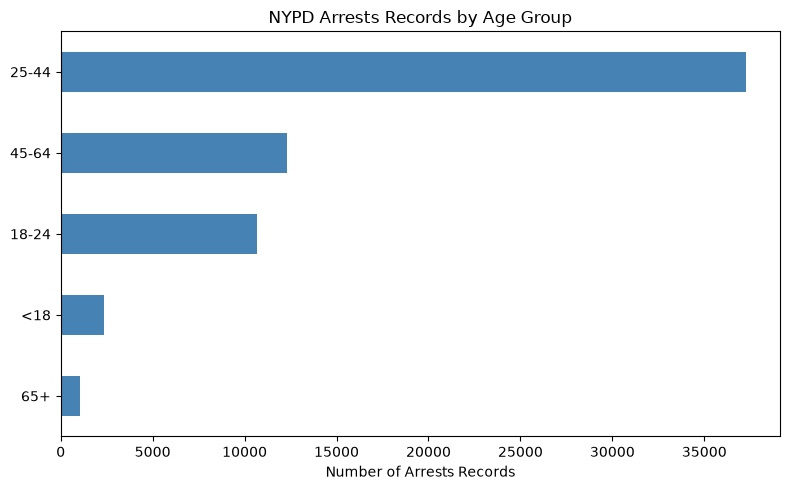

age_group
25-44    37254
45-64    12315
18-24    10684
<18       2327
65+       1041
Name: count, dtype: int64

In [55]:
plot_category_counts(
    cleaned_arrests_df,
    column= "age_group",
    title="NYPD Arrests Records by Age Group",
    xlabel="Number of Arrests Records",
    color="steelblue",
)

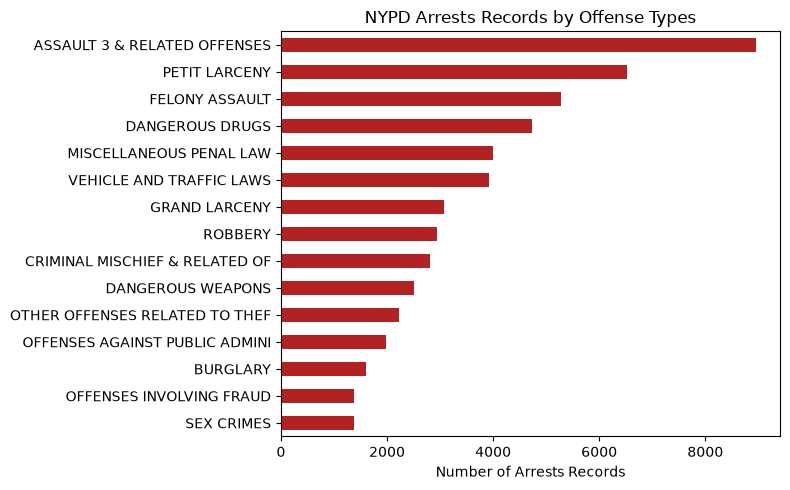

offense_type
ASSAULT 3 & RELATED OFFENSES      8960
PETIT LARCENY                     6526
FELONY ASSAULT                    5288
DANGEROUS DRUGS                   4733
MISCELLANEOUS PENAL LAW           3992
VEHICLE AND TRAFFIC LAWS          3923
GRAND LARCENY                     3068
ROBBERY                           2945
CRIMINAL MISCHIEF & RELATED OF    2817
DANGEROUS WEAPONS                 2509
OTHER OFFENSES RELATED TO THEF    2227
OFFENSES AGAINST PUBLIC ADMINI    1981
BURGLARY                          1599
OFFENSES INVOLVING FRAUD          1384
SEX CRIMES                        1383
Name: count, dtype: int64

In [56]:
plot_category_counts(
    cleaned_arrests_df,
    column= "offense_type",
    title="NYPD Arrests Records by Offense Types",
    xlabel="Number of Arrests Records",
    top_n=15,
    color="firebrick",
)

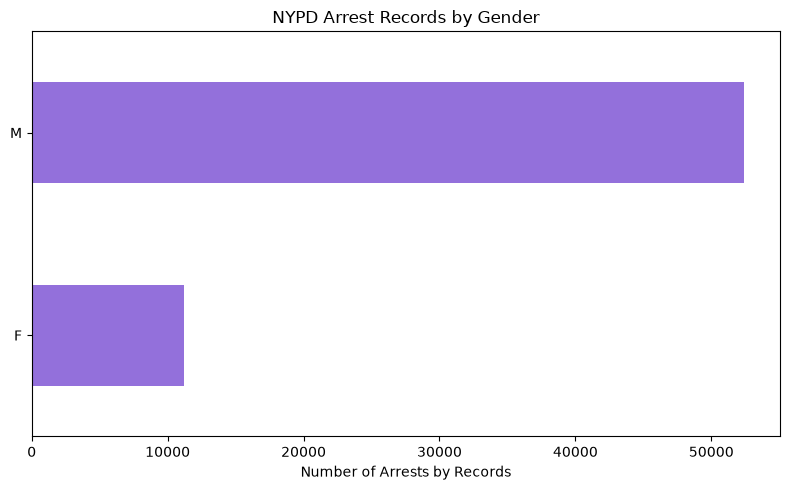

gender
M    52432
F    11189
Name: count, dtype: int64

In [57]:
plot_category_counts(
    cleaned_arrests_df,
    column="gender",
    title= "NYPD Arrest Records by Gender",
    xlabel= "Number of Arrests by Records",
    color="mediumpurple"
)

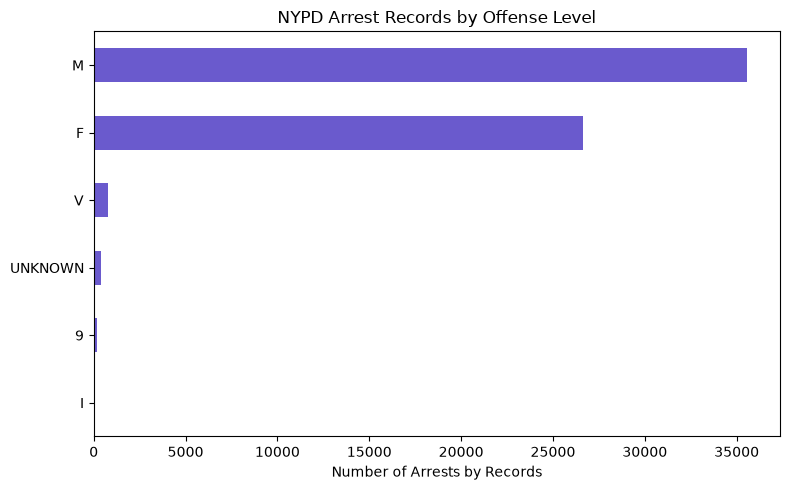

offense_level
M          35580
F          26653
V            775
UNKNOWN      404
9            155
I             54
Name: count, dtype: int64

In [58]:
plot_category_counts(
    cleaned_arrests_df,
    column="offense_level",
    title= "NYPD Arrest Records by Offense Level",
    xlabel= "Number of Arrests by Records",
    color="slateblue"
)

In [59]:
# Create a geographical dataframe 

MAP_COLUMNS = [
    "arrest_key",
    "arrest_date",
    "borough",
    "offense_type",
    "offense_level",
    "age_group",
    "gender",
    "race",
    "latitude",
    "longitude",
]

map_df = cleaned_arrests_df[MAP_COLUMNS].dropna(
    subset=["latitude","longitude"]
).copy()

map_df = map_df[
    map_df["latitude"].between(40.45,41.00)
    & map_df["longitude"].between(-74.30, -73.65)
].copy()

print(
    f"Records available for mapping: {len(map_df):,}"
)

map_df.head()

Records available for mapping: 63,619


,arrest_key,arrest_date,borough,offense_type,offense_level,age_group,gender,race,latitude,longitude
0,280255493,2024-01-10,M,ROBBERY,F,<18,M,BLACK,40.814845,-73.956312
1,279805419,2024-01-02,K,RAPE,F,25-44,M,WHITE HISPANIC,40.674496,-73.930571
2,279895750,2024-01-03,Q,ASSAULT 3 & RELATED OFFENSES,M,65+,F,WHITE,40.662526,-73.846499
3,280809090,2024-01-19,B,DANGEROUS DRUGS,M,45-64,M,BLACK,40.855793,-73.843908
4,280357135,2024-01-11,K,FELONY ASSAULT,F,25-44,F,BLACK,40.694456,-73.934343


In [60]:
print(f"Rows: {len(cleaned_arrests_df):,}")
print(f"Columns: {cleaned_arrests_df.shape[1]}")
print(
    "Duplicate arrest keys:",
    cleaned_arrests_df["arrest_key"].duplicated().sum(),
)

print("\nColumn data types:")
print(cleaned_arrests_df.dtypes)

print("\nMissing values:")
print(
    cleaned_arrests_df.isna()
    .sum()
    .sort_values(ascending=False)
)

Rows: 63,621
Columns: 19
Duplicate arrest keys: 0

Column data types:
arrest_key                       int64
arrest_date             datetime64[us]
pd_code                          Int64
pd_description                     str
key_code                         Int64
offense_type                       str
law_code                           str
offense_level                      str
borough                            str
jurisdiction_code                int64
arrest_precinct                  int64
age_group                          str
gender                             str
race                               str
x_coordinate                     int64
y_coordinate                     int64
latitude                       float64
longitude                      float64
georeferenced_column               str
dtype: object

Missing values:
pd_description          9
key_code                9
pd_code                 2
law_code                2
arrest_key              0
arrest_date             0
of

In [61]:
processed_directory = Path(
    "data/processed"
)

processed_directory.mkdir(
    parents=True,
    exist_ok=True,
)

output_path = (
    processed_directory
    / "nypd_arrests_clean.csv"
)

cleaned_arrests_df.to_csv(
    output_path,
    index=False,
    date_format="%Y-%m-%d",
)

print(
    f"Exported {len(cleaned_arrests_df):,} "
    f"cleaned records to:\n{output_path}"
)

Exported 63,621 cleaned records to:
data\processed\nypd_arrests_clean.csv
